# Task 2 — Notebook 6: Train, Tune, Evaluate

**Objective:**
- Start with a **simple baseline** so we know what a real model has to beat
- Train a model, then **tune it using the validation split**
- Choose a **metric that fits an imbalanced problem** — not accuracy alone
- Touch the **test set only once**, at the very end
- **Artifact:** the trained model and a results summary

> Reads `train_features.parquet`, `validation_features.parquet`, `test_features.parquet` from Notebook 5.
> The test set is not opened until the very last section of this notebook.

In [21]:
import importlib
import src.mlflow_logging as mlflow_logging

importlib.reload(mlflow_logging)

print(mlflow_logging.log_model_parameters)

<function log_model_parameters at 0x00000236FC416EF0>


In [23]:
import ast

best_config = ast.literal_eval(best_config)

print(type(best_config))
print(best_config)

<class 'dict'>
{'n_estimators': 200, 'max_depth': 10, 'min_samples_leaf': 20}


In [22]:
print(type(best_config))
print(best_config)

<class 'str'>
{'n_estimators': 200, 'max_depth': 10, 'min_samples_leaf': 20}


In [27]:
import ast
import joblib
import mlflow

from src.mlflow_config import configure_mlflow
from src.mlflow_logging import (
    log_model_parameters,
    log_model_metrics,
    log_artifacts_and_model,
    load_metrics_from_results,
)

configure_mlflow()

results = load_metrics_from_results()

model = joblib.load("models/late_delivery_model.joblib")

best_config = ast.literal_eval(results["best_config"])
final_metrics = results["final_test_metrics"]
best_threshold = results["chosen_threshold"]

with mlflow.start_run(run_name="final_model"):

    log_model_parameters(
        model_type="RandomForestClassifier",
        hyperparams=best_config
    )

    mlflow.log_param(
        "classification_threshold",
        best_threshold
    )

    log_model_metrics(final_metrics)

    log_artifacts_and_model(
        model,
        model_name="late_delivery_classifier"
    )

    print("MLflow run completed successfully.")
    print("Run ID:", mlflow.active_run().info.run_id)

MLflow run completed successfully.
Run ID: 7e060a83e926442c91b520d1e9eda815


Successfully registered model 'late_delivery_classifier'.
Created version '1' of model 'late_delivery_classifier'.


In [28]:
import mlflow

run = mlflow.get_run("7e060a83e926442c91b520d1e9eda815")

print("Run ID:", run.info.run_id)
print("Status:", run.info.status)

print("\nParameters:")
print(run.data.params)

print("\nMetrics:")
print(run.data.metrics)

print("\nTags:")
print(run.data.tags)

Run ID: 7e060a83e926442c91b520d1e9eda815
Status: FINISHED

Parameters:
{'classification_threshold': '0.3889831613985246', 'max_depth': '10', 'min_samples_leaf': '20', 'model_type': 'RandomForestClassifier', 'n_estimators': '200'}

Metrics:
{'accuracy': 0.8289682813903669, 'f1': 0.15844950697041824, 'precision': 0.11743951612903226, 'pr_auc': 0.10590576095431956, 'recall': 0.24346917450365727, 'roc_auc': 0.6808224266517836}

Tags:
{'mlflow.log-model.history': '[{"run_id": "7e060a83e926442c91b520d1e9eda815", "artifact_path": "model", "utc_time_created": "2026-09-23 16:58:13.432714", "flavors": {"python_function": {"model_path": "model.pkl", "predict_fn": "predict", "loader_module": "mlflow.sklearn", "python_version": "3.10.11", "env": {"conda": "conda.yaml", "virtualenv": "python_env.yaml"}}, "sklearn": {"pickled_model": "model.pkl", "sklearn_version": "1.2.2", "serialization_format": "cloudpickle", "code": null}}, "model_uuid": "e86bb984e1e8422c8d25f4ec5aa6d0dd", "mlflow_version": "2.15

In [29]:
import mlflow

client = mlflow.MlflowClient()

artifacts = client.list_artifacts(
    "7e060a83e926442c91b520d1e9eda815"
)

for artifact in artifacts:
    print(artifact.path, "|", artifact.is_dir)

features | True
model | True
transformers | True


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import json
import os
import mlflow
from src.mlflow_config import configure_mlflow
from src.mlflow_logging import (
    log_model_parameters,
    log_model_metrics,
    log_artifacts_and_model,
)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    average_precision_score, roc_auc_score, precision_recall_curve,
    confusion_matrix, classification_report
)

os.makedirs("artifacts/charts", exist_ok=True)
os.makedirs("artifacts/model", exist_ok=True)

train_features = pd.read_parquet("data/train_features.parquet")
val_features = pd.read_parquet("data/validation_features.parquet")
test_features = pd.read_parquet("data/test_features.parquet")

label_col = "is_late"
feature_cols = [c for c in train_features.columns if c != label_col]

X_train, y_train = train_features[feature_cols], train_features[label_col]
X_val, y_val = val_features[feature_cols], val_features[label_col]
X_test, y_test = test_features[feature_cols], test_features[label_col]

print("Train:", X_train.shape, "| Val:", X_val.shape, "| Test:", X_test.shape)
print("Train label rate:", y_train.mean().round(4), "| Val label rate:", y_val.mean().round(4))

Train: (67529, 64) | Val: (14470, 64) | Test: (14471, 64)
Train label rate: 0.0903 | Val label rate: 0.0534


## 1. Choosing the metric — before touching any model

From Notebook 2/4: the label is heavily imbalanced (**~92% on-time / ~8% late**). This decides which metric
we optimize for **before** we train anything:

- **Accuracy is misleading here.** A model that always predicts "on time" scores ~92% accuracy while being
  completely useless — it never catches a single late order.
- We need a metric that reflects performance on the **minority class** (`is_late = 1`), since that's the
  class the business actually cares about catching.
- **Primary metric: PR-AUC (average precision)** — better suited than ROC-AUC for imbalanced problems, since
  it focuses on the positive class and isn't inflated by the large number of easy true negatives.
- **Secondary metrics:** F1-score, Precision, and Recall on `is_late = 1`, plus a confusion matrix for a
  human-readable view of the trade-off.

All model comparisons and tuning below are driven by **validation PR-AUC**, not accuracy.

## 2. Baseline — know what we have to beat

A `DummyClassifier` that always predicts the majority class (`is_late = 0`). If our real model can't beat
this by a meaningful margin on the metrics that matter, it isn't adding value.

In [ ]:
import joblib
from pathlib import Path

model_path = Path("models/late_delivery_model.joblib")

print("Model exists:", model_path.exists())

if model_path.exists():
    loaded_model = joblib.load(model_path)
    print("Model type:", type(loaded_model).__name__)
    print("Number of features:", loaded_model.n_features_in_)

Best config:
{'n_estimators': 200, 'max_depth': 10, 'min_samples_leaf': 20}

Chosen threshold:
0.3889831613985246

Final test metrics:
model: Final model (test set)
accuracy: 0.8289682813903669
precision: 0.11743951612903226
recall: 0.24346917450365727
f1: 0.15844950697041824
roc_auc: 0.6808224266517836
pr_auc: 0.10590576095431956


In [19]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_val)
baseline_proba = baseline.predict_proba(X_val)[:, 1]

def evaluate(y_true, y_pred, y_proba, name):
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba),
    }

results = []
results.append(evaluate(y_val, baseline_pred, baseline_proba, "Baseline (majority class)"))
pd.DataFrame(results)

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Baseline (majority class),0.946579,0.0,0.0,0.0,0.5,0.053421


**Note:** the baseline shows exactly the accuracy trap described above — high accuracy, but zero
recall/F1/PR-AUC, because it never predicts the positive class at all. Any real model must clearly beat the
PR-AUC and F1 columns here, not the accuracy column.

## 3. Train a first real model

We try two model families with `class_weight="balanced"` (to counteract the imbalance during training
itself, in addition to using the right evaluation metric), and compare them on the validation set.

In [4]:
log_reg = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

lr_pred = log_reg.predict(X_val)
lr_proba = log_reg.predict_proba(X_val)[:, 1]
results.append(evaluate(y_val, lr_pred, lr_proba, "Logistic Regression (balanced)"))

rf = RandomForestClassifier(class_weight="balanced", n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_val)
rf_proba = rf.predict_proba(X_val)[:, 1]
results.append(evaluate(y_val, rf_pred, rf_proba, "Random Forest (balanced, default depth)"))

pd.DataFrame(results)

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Baseline (majority class),0.946579,0.000000,0.000000,0.000000,0.500000,0.053421
1,Logistic Regression (balanced),0.875881,0.186773,0.394567,0.253533,0.767890,0.160079
2,"Random Forest (balanced, default depth)",0.945681,0.066667,0.001294,0.002538,0.632097,0.081320
3,Logistic Regression (balanced),0.875881,0.186773,0.394567,0.253533,0.767890,0.160079
4,"Random Forest (balanced, default depth)",0.945681,0.066667,0.001294,0.002538,0.632097,0.081320


**Model selection decision (fill in after seeing the table above):**
- Which model has the higher validation PR-AUC?
- Is the gap large enough to justify the extra complexity of Random Forest over Logistic Regression?
- We proceed to hyperparameter tuning with whichever model wins on PR-AUC.

## 4. Hyperparameter tuning — using the validation split

Since our train/validation split is **time-based** (not random), standard k-fold cross-validation would mix
future and past data across folds — the same leakage problem we avoided in Notebook 3. Instead, we tune
manually: train each candidate configuration on `train`, score it on `validation`, and keep the best one.
This mirrors exactly how the split was designed to be used.

In [5]:
param_grid = [
    {"n_estimators": 200, "max_depth": 6, "min_samples_leaf": 20},
    {"n_estimators": 200, "max_depth": 10, "min_samples_leaf": 20},
    {"n_estimators": 300, "max_depth": 10, "min_samples_leaf": 50},
    {"n_estimators": 300, "max_depth": 14, "min_samples_leaf": 50},
    {"n_estimators": 300, "max_depth": None, "min_samples_leaf": 100},
]

tuning_results = []
fitted_models = {}

for params in param_grid:
    model = RandomForestClassifier(
        class_weight="balanced", random_state=42, n_jobs=-1, **params
    )
    model.fit(X_train, y_train)

    val_proba = model.predict_proba(X_val)[:, 1]
    val_pred = model.predict(X_val)

    row = evaluate(y_val, val_pred, val_proba, str(params))
    tuning_results.append(row)
    fitted_models[str(params)] = model

tuning_df = pd.DataFrame(tuning_results).sort_values("pr_auc", ascending=False)
tuning_df

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
1,"{'n_estimators': 200, 'max_depth': 10, 'min_sa...",0.932412,0.166124,0.065977,0.094444,0.650931,0.102194
2,"{'n_estimators': 300, 'max_depth': 10, 'min_sa...",0.930339,0.151335,0.065977,0.091892,0.643055,0.100326
3,"{'n_estimators': 300, 'max_depth': 14, 'min_sa...",0.928265,0.146667,0.071151,0.095819,0.638321,0.098935
0,"{'n_estimators': 200, 'max_depth': 6, 'min_sam...",0.941534,0.212598,0.034929,0.060000,0.638088,0.095700
4,"{'n_estimators': 300, 'max_depth': None, 'min_...",0.924672,0.128806,0.071151,0.091667,0.625533,0.094375


In [6]:
best_config = tuning_df.iloc[0]["model"]
best_model = fitted_models[best_config]

print("Best config by validation PR-AUC:", best_config)
print("Validation PR-AUC:", tuning_df.iloc[0]["pr_auc"].round(4))

Best config by validation PR-AUC: {'n_estimators': 200, 'max_depth': 10, 'min_samples_leaf': 20}
Validation PR-AUC: 0.1022


## 5. Threshold tuning

By default, classifiers use a 0.5 probability threshold to decide the predicted class — but for an imbalanced
problem, 0.5 is rarely optimal. We scan thresholds on the **validation** set and pick the one that maximizes
F1 for the positive class.

Best threshold: 0.389
Validation F1 at this threshold: 0.1705
Validation precision: 0.1172 | recall: 0.3131


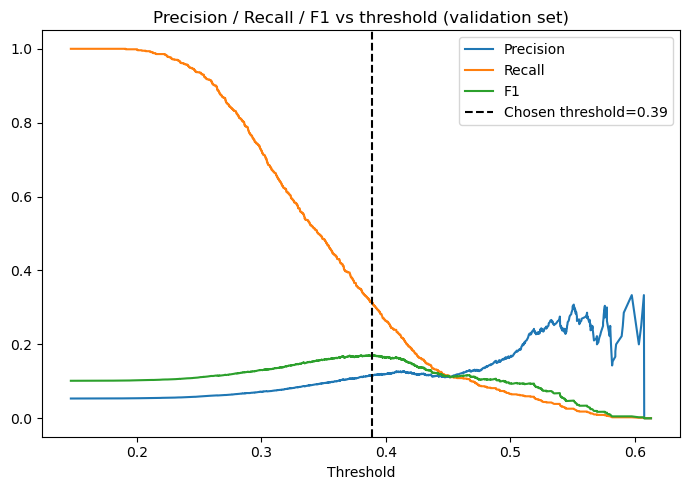

In [7]:
val_proba_best = best_model.predict_proba(X_val)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_val, val_proba_best)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)

best_idx = np.argmax(f1_scores[:-1])  # last point has no corresponding threshold
best_threshold = thresholds[best_idx]

print(f"Best threshold: {best_threshold:.3f}")
print(f"Validation F1 at this threshold: {f1_scores[best_idx]:.4f}")
print(f"Validation precision: {precisions[best_idx]:.4f} | recall: {recalls[best_idx]:.4f}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(thresholds, precisions[:-1], label="Precision")
ax.plot(thresholds, recalls[:-1], label="Recall")
ax.plot(thresholds, f1_scores[:-1], label="F1")
ax.axvline(best_threshold, color="black", linestyle="--", label=f"Chosen threshold={best_threshold:.2f}")
ax.set_xlabel("Threshold")
ax.legend()
ax.set_title("Precision / Recall / F1 vs threshold (validation set)")
plt.tight_layout()
plt.savefig("artifacts/charts/threshold_tuning.png", dpi=120)
plt.show()

## 6. Feature importance (sanity check against the EDA)

Before touching the test set, we check whether the model's learned feature importances agree with what the
EDA found — geography (`customer_state` / `primary_seller_state` / `same_state`) should show up as important
if our earlier analysis was right.

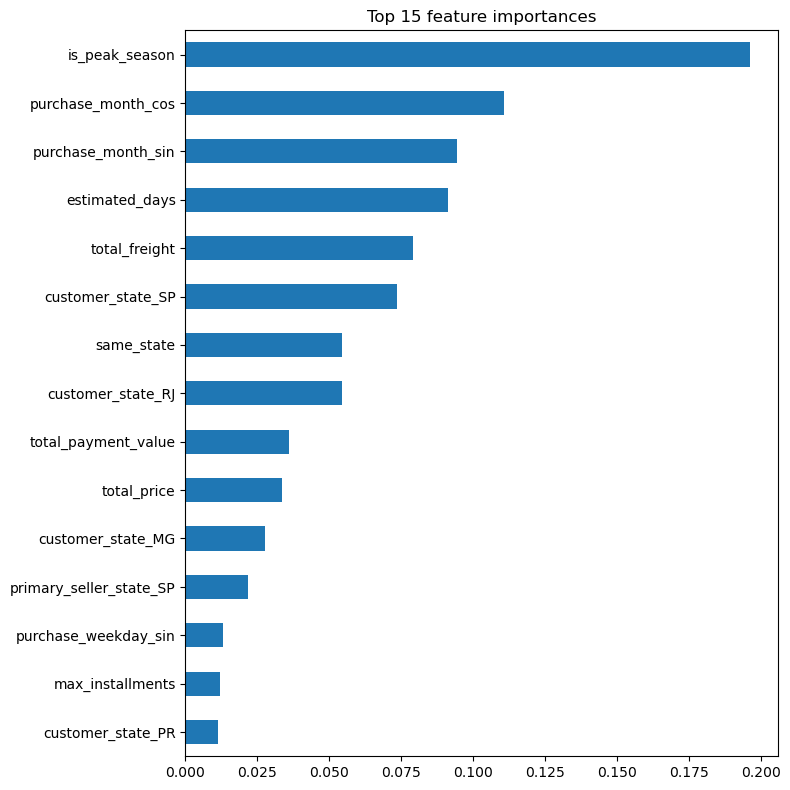

is_peak_season             0.196059
purchase_month_cos         0.110863
purchase_month_sin         0.094475
estimated_days             0.091218
total_freight              0.078928
customer_state_SP          0.073589
same_state                 0.054473
customer_state_RJ          0.054292
total_payment_value        0.035899
total_price                0.033643
customer_state_MG          0.027679
primary_seller_state_SP    0.021854
purchase_weekday_sin       0.012885
max_installments           0.012163
customer_state_PR          0.011471
dtype: float64

In [8]:
importances = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 8))
importances.head(15).sort_values().plot(kind="barh", ax=ax)
ax.set_title("Top 15 feature importances")
plt.tight_layout()
plt.savefig("artifacts/charts/feature_importance.png", dpi=120)
plt.show()

importances.head(15)

**Notes (fill in after seeing the chart above):**
- Do geography-related features (`customer_state_*`, `primary_seller_state_*`, `same_state`) rank near the
  top, consistent with the EDA findings?
- Any surprising features that turned out important but weren't flagged in the EDA?

## 7. Final evaluation — touch the test set once

This is the **only** point in the entire track where `test_features.parquet` is opened. We evaluate the
final chosen model (best hyperparameters + best threshold, both selected using validation only) on the test
set, and report the result as-is — no further tuning after this point.

In [9]:
test_proba = best_model.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= best_threshold).astype(int)

final_metrics = evaluate(y_test, test_pred, test_proba, "Final model (test set)")
print(json.dumps(final_metrics, indent=2))

print("\nClassification report (test set):")
print(classification_report(y_test, test_pred, target_names=["on time", "late"]))

{
  "model": "Final model (test set)",
  "accuracy": 0.8289682813903669,
  "precision": 0.11743951612903226,
  "recall": 0.24346917450365727,
  "f1": 0.15844950697041824,
  "roc_auc": 0.6808224266517836,
  "pr_auc": 0.10590576095431956
}

Classification report (test set):
              precision    recall  f1-score   support

     on time       0.94      0.87      0.90     13514
        late       0.12      0.24      0.16       957

    accuracy                           0.83     14471
   macro avg       0.53      0.56      0.53     14471
weighted avg       0.89      0.83      0.86     14471



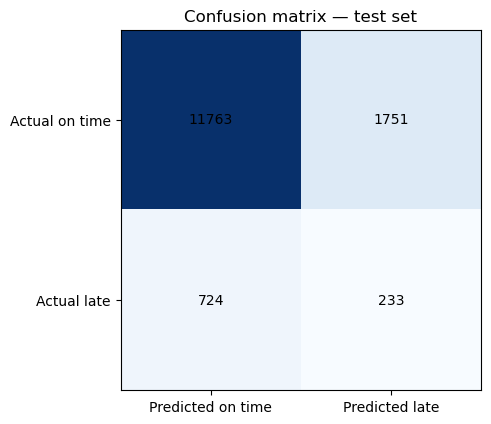

In [10]:
cm = confusion_matrix(y_test, test_pred)

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Predicted on time", "Predicted late"])
ax.set_yticklabels(["Actual on time", "Actual late"])
ax.set_title("Confusion matrix — test set")
plt.tight_layout()
plt.savefig("artifacts/charts/confusion_matrix_test.png", dpi=120)
plt.show()

**Final comparison — baseline vs. tuned model on their respective sets:**

| | Baseline (val) | Tuned model (test, final) |
|---|---|---|
| PR-AUC | (see section 2 table) | (see above) |
| F1 | (see section 2 table) | (see above) |
| Recall | (see section 2 table) | (see above) |

**Fill in after running:** does the final model clearly beat the baseline on PR-AUC and F1? By how much?
Is recall on the late class high enough to be useful in practice, or does precision/recall trade-off need
revisiting (e.g. by choosing a different threshold depending on business cost of false positives vs. false
negatives)?

## 8. Save artifacts

The trained model (with its chosen threshold) and a results summary — everything needed for a production
pipeline to reproduce this exact prediction behavior without retraining.

In [11]:
joblib.dump(best_model, "artifacts/model/late_delivery_model.joblib")

results_summary = {
    "baseline_validation_metrics": results[0],
    "candidate_models_validation": results[1:],
    "hyperparameter_tuning": tuning_df.to_dict(orient="records"),
    "best_config": best_config,
    "chosen_threshold": float(best_threshold),
    "final_test_metrics": final_metrics,
    "top_15_feature_importances": importances.head(15).to_dict(),
}

with open("artifacts/results_summary.json", "w", encoding="utf-8") as f:
    json.dump(results_summary, f, indent=2)

print("Saved:")
print(" - artifacts/model/late_delivery_model.joblib")
print(" - artifacts/results_summary.json")
print(" - artifacts/charts/threshold_tuning.png")
print(" - artifacts/charts/feature_importance.png")
print(" - artifacts/charts/confusion_matrix_test.png")

Saved:
 - artifacts/model/late_delivery_model.joblib
 - artifacts/results_summary.json
 - artifacts/charts/threshold_tuning.png
 - artifacts/charts/feature_importance.png
 - artifacts/charts/confusion_matrix_test.png


## ✅ Done when
- A working baseline is recorded, and the tuned model is clearly compared against it (PR-AUC / F1, not accuracy)
- Hyperparameters were tuned using validation only; the threshold was tuned using validation only
- The test set was opened **exactly once**, at the very end, with no further changes made afterward
- The trained model and a full results summary are saved as artifacts